In [15]:
%load_ext autoreload
%autoreload 2
import numpy as np
import matplotlib.pyplot as plt
import json
from simulations import run_sim

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [16]:
def plot_convergence(result, title):
    running_accuracies, convergence_metrics, params = result

    plt.figure(figsize=(12, 6))

    for run_number, run_acc in enumerate(running_accuracies, start=1):
        plt.plot(range(1, params['agents'] + 1), run_acc, label=f'Run {run_number}')

    plt.axhline(y=1.0, color='green', linestyle='--', linewidth=2)
    plt.axhline(y=0.0, color='red', linestyle='--', linewidth=2)

    plt.title(title)
    plt.xlabel('Agent Index (t)')
    plt.ylabel('Running Proportion of Correct Actions')
    plt.ylim(-0.05, 1.05)
    plt.grid(alpha=0.3)

    if params['runs'] <= 10:
        plt.legend(loc='center left', bbox_to_anchor=(1.0, 0.5), title='Simulation Run')

    plt.tight_layout()
    plt.show()


def summarise_convergence_metrics(result):
    rows = []
    for run_number, (converged, success, lock_in_index, final_accuracy) in enumerate(result.convergence_metrics, start=1):
        if converged is True and success is True:
            status = 'converged accurately'
        elif converged is True and success is False:
            status = 'converged inaccurately'
        elif converged is False:
            status = 'did not converge'
        else:
            status = 'unknown'

        rows.append((run_number, status, lock_in_index, final_accuracy))

    for run_number, status, lock_in_index, final_accuracy in rows:
        print(f"Run {run_number}: {status} | lock_in_index={lock_in_index} | final_accuracy={final_accuracy:.4f}")

    converged_runs = [
        run_number
        for run_number, status, _, _ in rows
        if status == 'converged accurately' or status == 'converged inaccurately'
    ]
    lock_in_indices = [
        lock_in_index
        for _, status, lock_in_index, _ in rows
        if lock_in_index is not None
    ]

    print(f"Converged runs: {converged_runs}")
    print(f"Lock-in indices: {lock_in_indices}")



In [3]:
from scipy.stats import norm
import math

k = 5
i = 4
j = k-i
q = 0.8
# q = norm.cdf(1)
Q = max(q, 1-q)
w = abs(np.log(q/(1-q)))
pb = 1/(2**k) * (sum([math.comb(k, j+l) for l in range(2, i+1)]) + 0.5*math.comb(k, j+1)*(1+Q) + math.comb(k, j)*Q + 0.5*math.comb(k, j-1)*Q)
pu = sum([(1/2**k)*math.comb(k, j+x)*norm.cdf(x*w/2 +1) for x in range(-j, i+1)])
gp = math.comb(k, i)*(Q)**i*(1-Q)**(k-i)
print(pb, gp)

0.91875 0.4096


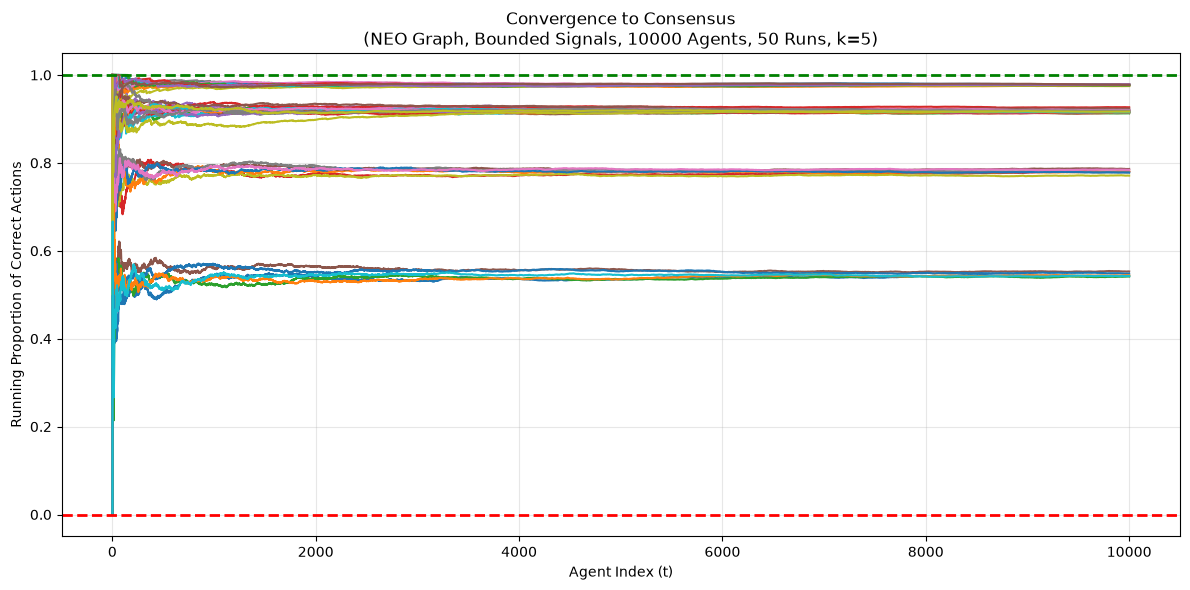

Run 1: did not converge | lock_in_index=None | final_accuracy=0.9792
Run 2: did not converge | lock_in_index=None | final_accuracy=0.9748
Run 3: did not converge | lock_in_index=None | final_accuracy=0.9127
Run 4: did not converge | lock_in_index=None | final_accuracy=0.7801
Run 5: did not converge | lock_in_index=None | final_accuracy=0.9174
Run 6: did not converge | lock_in_index=None | final_accuracy=0.5530
Run 7: did not converge | lock_in_index=None | final_accuracy=0.9207
Run 8: did not converge | lock_in_index=None | final_accuracy=0.9185
Run 9: did not converge | lock_in_index=None | final_accuracy=0.7710
Run 10: did not converge | lock_in_index=None | final_accuracy=0.9762
Run 11: did not converge | lock_in_index=None | final_accuracy=0.5427
Run 12: did not converge | lock_in_index=None | final_accuracy=0.7801
Run 13: did not converge | lock_in_index=None | final_accuracy=0.9157
Run 14: did not converge | lock_in_index=None | final_accuracy=0.9779
Run 15: did not converge | lo

In [4]:
# Theorem 1.
result = run_sim('NEO', 'bounded', agents=10000, runs=50, seed=123, k=5, q=0.8)

title = f"Convergence to Consensus\n({result.params['graph_type']} Graph, {result.params['signal_type'].title()} Signals, {result.params['agents']} Agents, {result.params['runs']} Runs, k={result.params['k']})"
plot_convergence(result, title)
summarise_convergence_metrics(result)


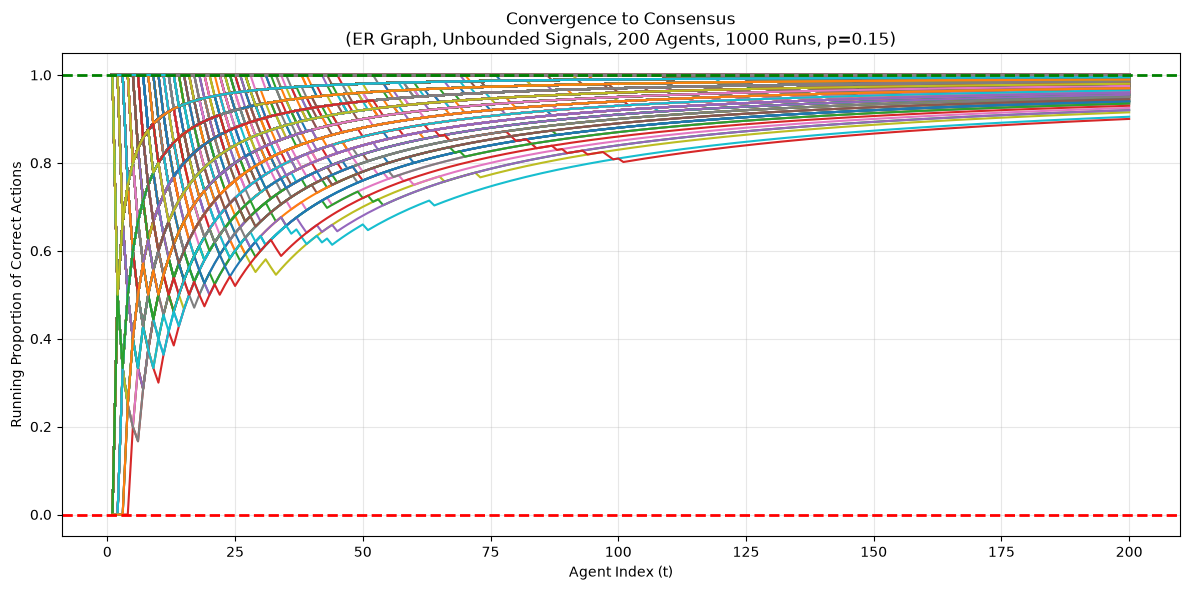

Run 1: converged accurately | lock_in_index=0 | final_accuracy=1.0000
Run 2: converged accurately | lock_in_index=44 | final_accuracy=0.9800
Run 3: converged accurately | lock_in_index=0 | final_accuracy=1.0000
Run 4: converged accurately | lock_in_index=13 | final_accuracy=0.9950
Run 5: converged accurately | lock_in_index=11 | final_accuracy=0.9900
Run 6: converged accurately | lock_in_index=12 | final_accuracy=0.9800
Run 7: converged accurately | lock_in_index=0 | final_accuracy=1.0000
Run 8: converged accurately | lock_in_index=14 | final_accuracy=0.9850
Run 9: converged accurately | lock_in_index=5 | final_accuracy=0.9900
Run 10: converged accurately | lock_in_index=0 | final_accuracy=1.0000
Run 11: converged accurately | lock_in_index=24 | final_accuracy=0.9850
Run 12: converged accurately | lock_in_index=0 | final_accuracy=1.0000
Run 13: converged accurately | lock_in_index=2 | final_accuracy=0.9950
Run 14: converged accurately | lock_in_index=13 | final_accuracy=0.9650
Run 15: 

In [50]:
# Theorem 2.
p_val = 0.15
result = run_sim('ER', 'unbounded', agents=200, runs=1000, seed=5427, p=p_val)

title = f"Convergence to Consensus\n({result.params['graph_type']} Graph, {result.params['signal_type'].title()} Signals, {result.params['agents']} Agents, {result.params['runs']} Runs, p={result.params['p']:.2f})"
plot_convergence(result, title)
summarise_convergence_metrics(result)


In [ ]:
from simulations import run_sim

print("Hunting for a false cascade seed...")

p_val = 0.8
agents_to_test = 100

for test_seed in range(1, 10000):
    # Run a single simulation per seed
    print(test_seed)
    result = run_sim('ER', 'unbounded', agents=agents_to_test, runs=1, seed=test_seed, p=p_val)
    
    # Extract the metrics for this single run
    converged, success, lock_time, final_accuracy = result.convergence_metrics[0]
    print(final_accuracy)
    
    # If the network locked in, but guessed WRONG
    if converged is True and success is False:
        print(f"Got one! Use seed={test_seed}")
        print(f"The false cascade locked in at agent {lock_time}.")
        print(f"The final accuracy was {final_accuracy:.4f}.")
        break

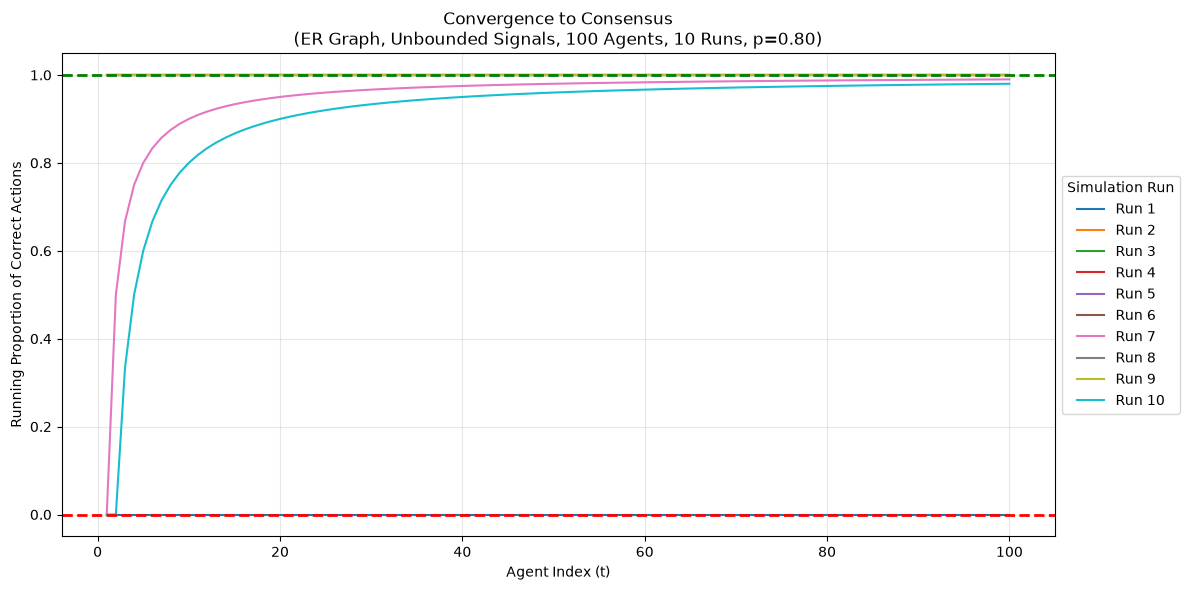

Run 1: converged inaccurately | lock_in_index=0 | final_accuracy=0.0000
Run 2: converged accurately | lock_in_index=0 | final_accuracy=1.0000
Run 3: converged accurately | lock_in_index=0 | final_accuracy=1.0000
Run 4: converged accurately | lock_in_index=0 | final_accuracy=1.0000
Run 5: converged accurately | lock_in_index=0 | final_accuracy=1.0000
Run 6: converged accurately | lock_in_index=0 | final_accuracy=1.0000
Run 7: converged accurately | lock_in_index=1 | final_accuracy=0.9900
Run 8: converged accurately | lock_in_index=0 | final_accuracy=1.0000
Run 9: converged accurately | lock_in_index=0 | final_accuracy=1.0000
Run 10: converged accurately | lock_in_index=2 | final_accuracy=0.9800
Converged runs: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10]
Lock-in indices: [0, 0, 0, 0, 0, 0, np.int64(1), 0, 0, np.int64(2)]


In [49]:
# Theorem 2 - issue.

p_val = 0.8
result = run_sim('ER', 'unbounded', agents=100, runs=10, seed=759, p=p_val)

title = f"Convergence to Consensus\n({result.params['graph_type']} Graph, {result.params['signal_type'].title()} Signals, {result.params['agents']} Agents, {result.params['runs']} Runs, p={result.params['p']:.2f})"
plot_convergence(result, title)
summarise_convergence_metrics(result)

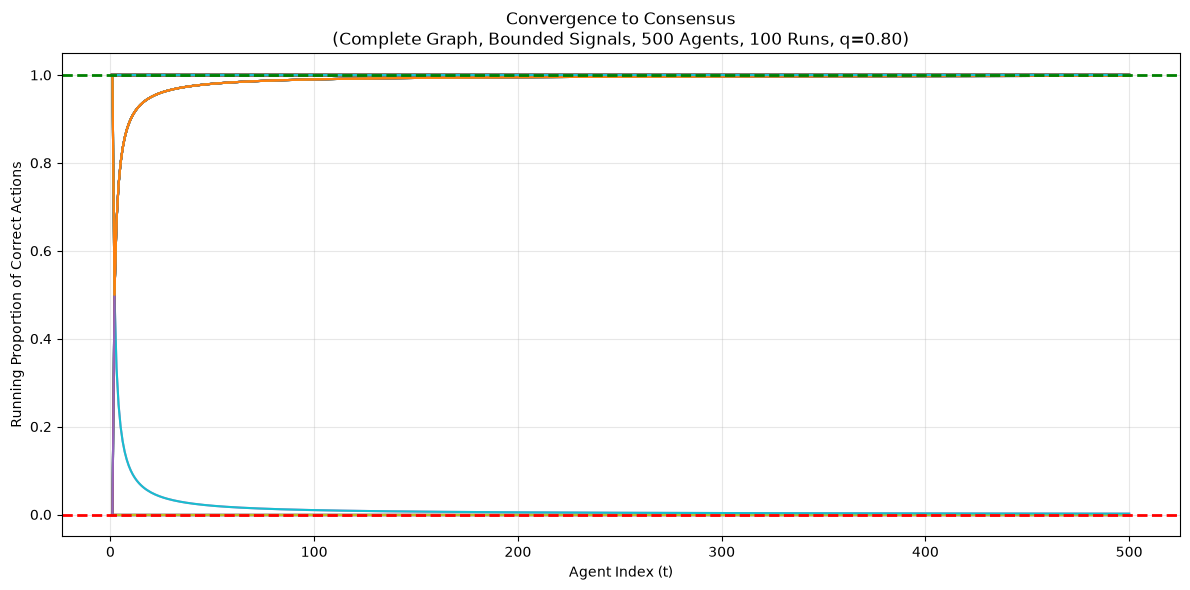

Run 1: converged accurately | lock_in_index=0 | final_accuracy=1.0000
Run 2: converged accurately | lock_in_index=0 | final_accuracy=1.0000
Run 3: converged accurately | lock_in_index=2 | final_accuracy=0.9980
Run 4: converged accurately | lock_in_index=0 | final_accuracy=1.0000
Run 5: converged accurately | lock_in_index=0 | final_accuracy=1.0000
Run 6: converged accurately | lock_in_index=2 | final_accuracy=0.9980
Run 7: converged inaccurately | lock_in_index=2 | final_accuracy=0.0020
Run 8: converged accurately | lock_in_index=0 | final_accuracy=1.0000
Run 9: converged accurately | lock_in_index=0 | final_accuracy=1.0000
Run 10: converged inaccurately | lock_in_index=0 | final_accuracy=0.0000
Run 11: converged accurately | lock_in_index=1 | final_accuracy=0.9980
Run 12: converged accurately | lock_in_index=0 | final_accuracy=1.0000
Run 13: converged accurately | lock_in_index=0 | final_accuracy=1.0000
Run 14: converged accurately | lock_in_index=0 | final_accuracy=1.0000
Run 15: con

In [8]:
# Theorem 3i.
result = run_sim('complete', 'bounded', agents=500, runs=100, seed=123, q=0.8)

title = f"Convergence to Consensus\n({result.params['graph_type'].title()} Graph, {result.params['signal_type'].title()} Signals, {result.params['agents']} Agents, {result.params['runs']} Runs, q={result.params['q']:.2f})"
plot_convergence(result, title)
summarise_convergence_metrics(result)


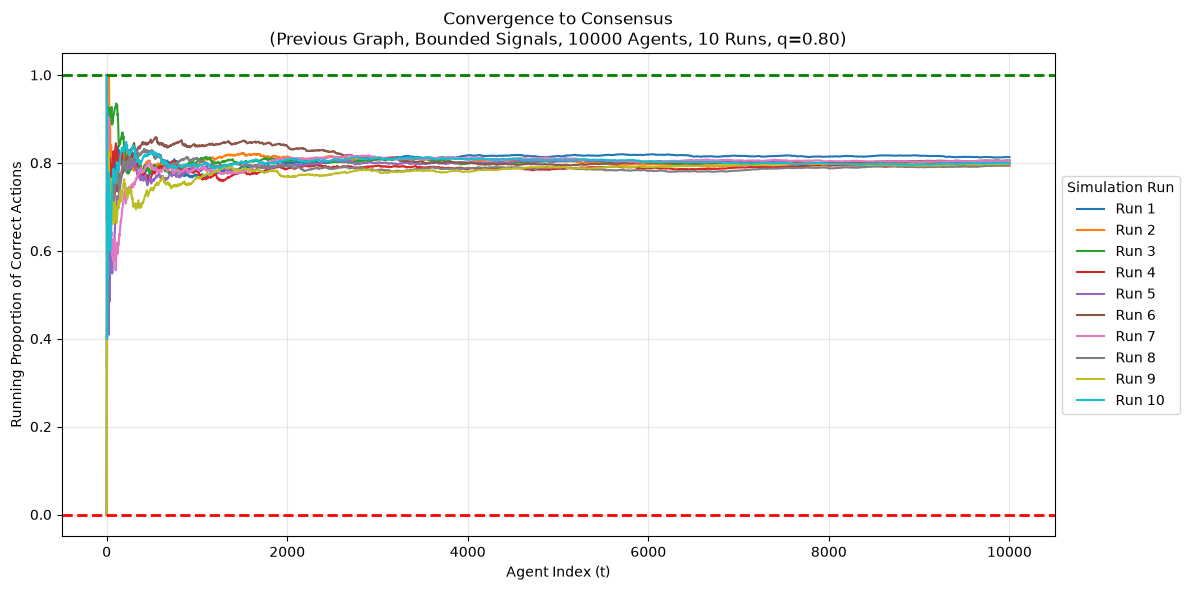

Run 1: did not converge | lock_in_index=None | final_accuracy=0.8132
Run 2: did not converge | lock_in_index=None | final_accuracy=0.8005
Run 3: did not converge | lock_in_index=None | final_accuracy=0.7997
Run 4: did not converge | lock_in_index=None | final_accuracy=0.7944
Run 5: did not converge | lock_in_index=None | final_accuracy=0.8006
Run 6: did not converge | lock_in_index=None | final_accuracy=0.8057
Run 7: did not converge | lock_in_index=None | final_accuracy=0.8044
Run 8: did not converge | lock_in_index=None | final_accuracy=0.7944
Run 9: did not converge | lock_in_index=None | final_accuracy=0.7980
Run 10: did not converge | lock_in_index=None | final_accuracy=0.7994
Converged runs: []
Lock-in indices: []


In [31]:
# Theorem 3ii.
result = run_sim('previous', 'bounded', agents=10000, runs=10, seed=123, q=0.8)

title = f"Convergence to Consensus\n({result.params['graph_type'].title()} Graph, {result.params['signal_type'].title()} Signals, {result.params['agents']} Agents, {result.params['runs']} Runs, q={result.params['q']:.2f})"
plot_convergence(result, title)
summarise_convergence_metrics(result)


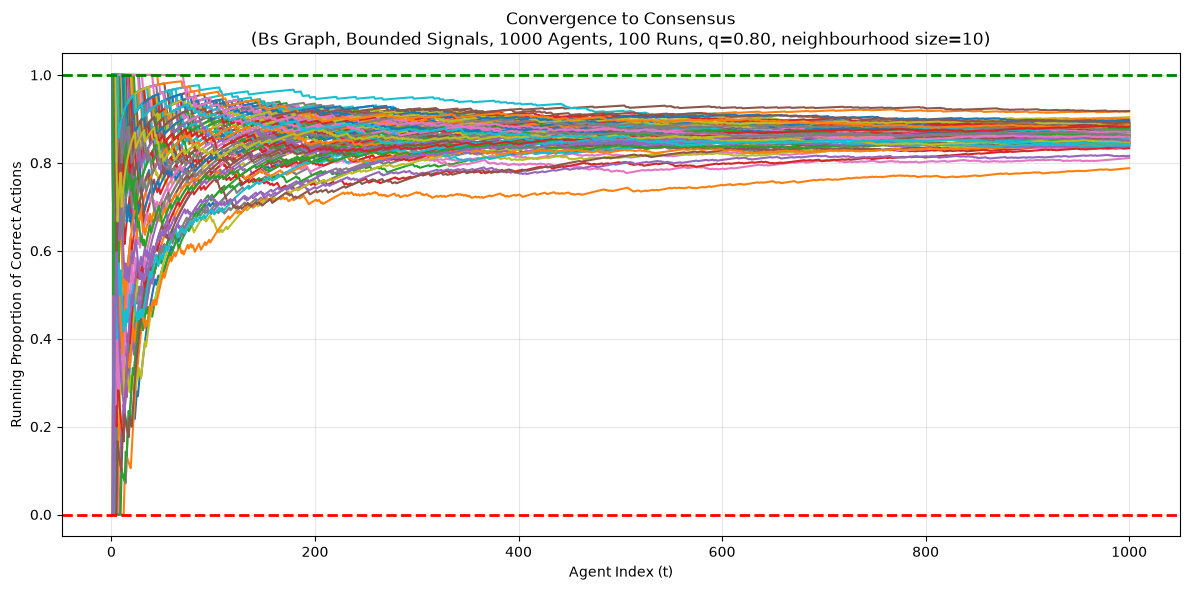

Run 1: did not converge | lock_in_index=None | final_accuracy=0.8620
Run 2: did not converge | lock_in_index=None | final_accuracy=0.8870
Run 3: did not converge | lock_in_index=None | final_accuracy=0.8780
Run 4: did not converge | lock_in_index=None | final_accuracy=0.8390
Run 5: did not converge | lock_in_index=None | final_accuracy=0.8820
Run 6: did not converge | lock_in_index=None | final_accuracy=0.8720
Run 7: did not converge | lock_in_index=None | final_accuracy=0.8630
Run 8: did not converge | lock_in_index=None | final_accuracy=0.8380
Run 9: did not converge | lock_in_index=None | final_accuracy=0.9040
Run 10: did not converge | lock_in_index=None | final_accuracy=0.8690
Run 11: did not converge | lock_in_index=None | final_accuracy=0.8640
Run 12: did not converge | lock_in_index=None | final_accuracy=0.9170
Run 13: did not converge | lock_in_index=None | final_accuracy=0.8600
Run 14: did not converge | lock_in_index=None | final_accuracy=0.8570
Run 15: did not converge | lo

In [24]:
# Theorem 3iii.
result = run_sim('BS', 'bounded', agents=1000, runs=100, seed=123, q = 0.8, sample=10)

title = f"Convergence to Consensus\n({result.params['graph_type'].title()} Graph, {result.params['signal_type'].title()} Signals, {result.params['agents']} Agents, {result.params['runs']} Runs, q={result.params['q']:.2f}, neighbourhood size={result.params['sample']})"
plot_convergence(result, title)
summarise_convergence_metrics(result)


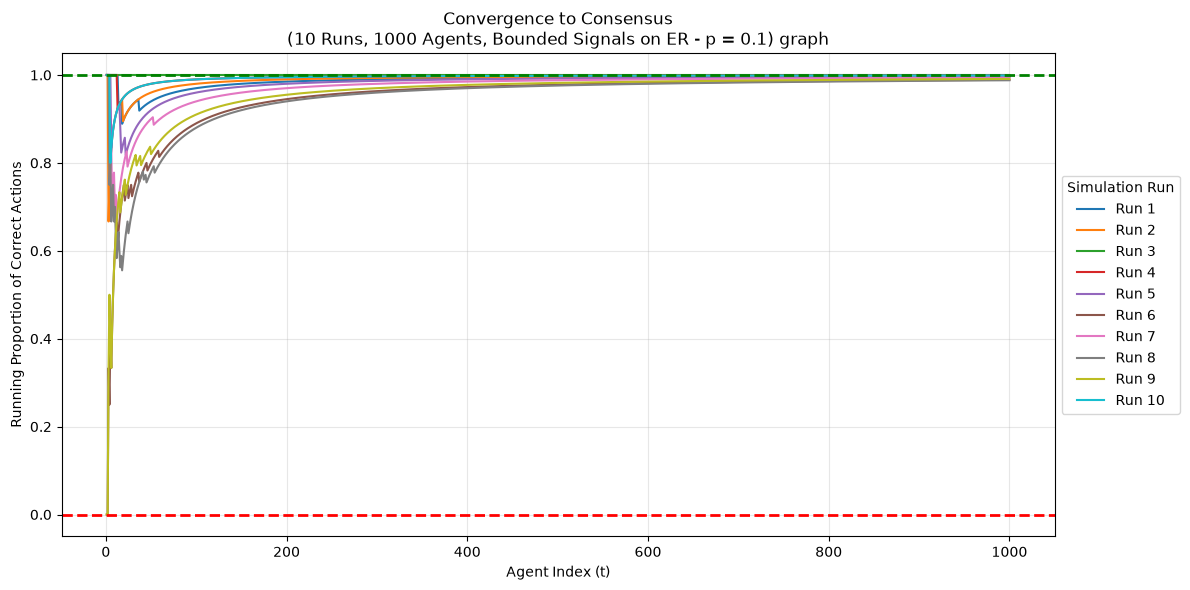

Run 1: converged accurately | lock_in_index=37 | final_accuracy=0.9970
Run 2: converged accurately | lock_in_index=19 | final_accuracy=0.9980
Run 3: converged accurately | lock_in_index=0 | final_accuracy=1.0000
Run 4: converged accurately | lock_in_index=13 | final_accuracy=0.9990
Run 5: converged accurately | lock_in_index=22 | final_accuracy=0.9960
Run 6: converged accurately | lock_in_index=59 | final_accuracy=0.9890
Run 7: converged accurately | lock_in_index=53 | final_accuracy=0.9940
Run 8: converged accurately | lock_in_index=54 | final_accuracy=0.9880
Run 9: converged accurately | lock_in_index=50 | final_accuracy=0.9910
Run 10: converged accurately | lock_in_index=5 | final_accuracy=0.9990
Converged runs: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10]
Lock-in indices: [37, 19, 0, 13, 22, 59, 53, 54, 50, 5]


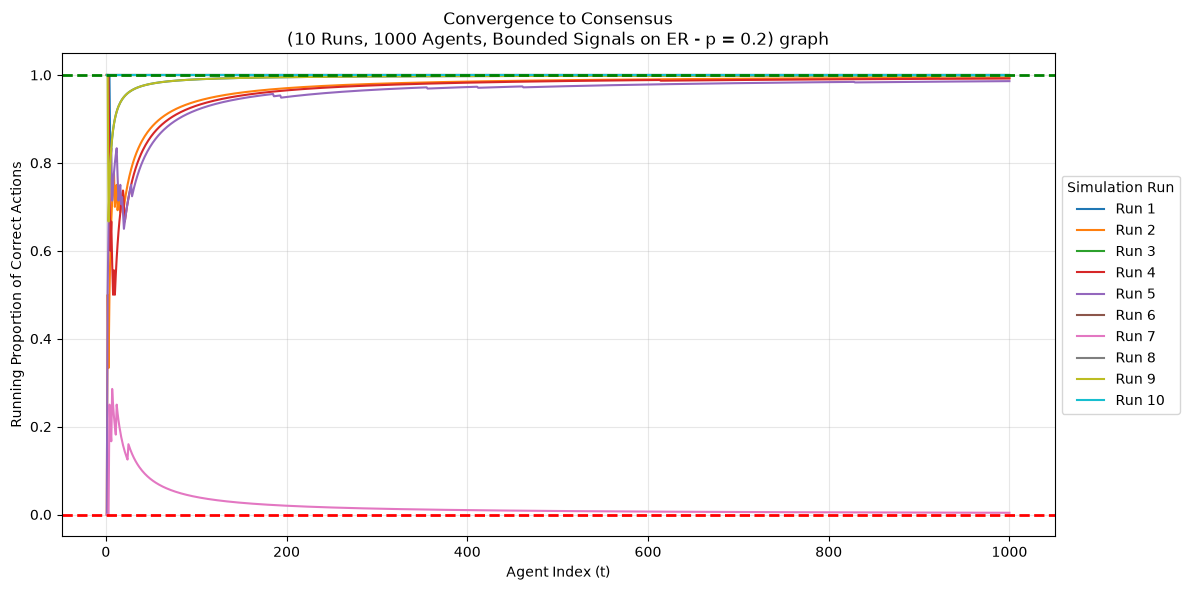

Run 1: converged accurately | lock_in_index=5 | final_accuracy=0.9990
Run 2: did not converge | lock_in_index=None | final_accuracy=0.9930
Run 3: converged accurately | lock_in_index=0 | final_accuracy=1.0000
Run 4: converged accurately | lock_in_index=614 | final_accuracy=0.9920
Run 5: did not converge | lock_in_index=None | final_accuracy=0.9860
Run 6: converged accurately | lock_in_index=0 | final_accuracy=1.0000
Run 7: converged inaccurately | lock_in_index=25 | final_accuracy=0.0040
Run 8: converged accurately | lock_in_index=0 | final_accuracy=1.0000
Run 9: converged accurately | lock_in_index=3 | final_accuracy=0.9990
Run 10: converged accurately | lock_in_index=0 | final_accuracy=1.0000
Converged runs: [1, 3, 4, 6, 7, 8, 9, 10]
Lock-in indices: [5, 0, 614, 0, 25, 0, 3, 0]


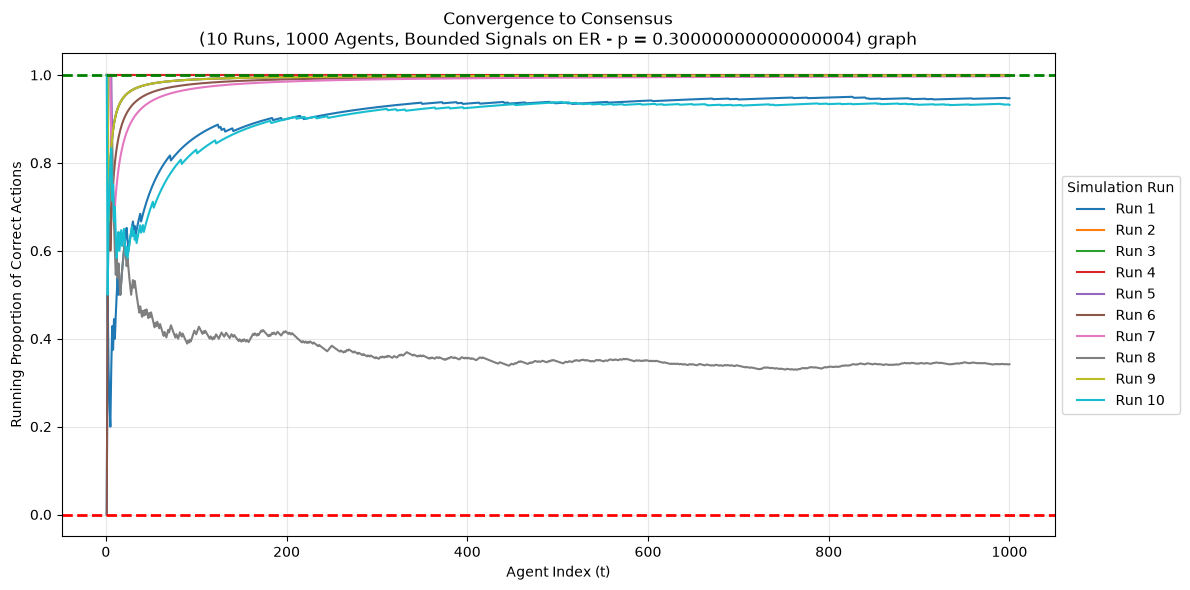

Run 1: did not converge | lock_in_index=None | final_accuracy=0.9470
Run 2: converged accurately | lock_in_index=0 | final_accuracy=1.0000
Run 3: converged accurately | lock_in_index=6 | final_accuracy=0.9990
Run 4: converged accurately | lock_in_index=0 | final_accuracy=1.0000
Run 5: converged accurately | lock_in_index=7 | final_accuracy=0.9990
Run 6: converged accurately | lock_in_index=5 | final_accuracy=0.9980
Run 7: converged accurately | lock_in_index=9 | final_accuracy=0.9970
Run 8: did not converge | lock_in_index=None | final_accuracy=0.3420
Run 9: converged accurately | lock_in_index=3 | final_accuracy=0.9990
Run 10: did not converge | lock_in_index=None | final_accuracy=0.9320
Converged runs: [2, 3, 4, 5, 6, 7, 9]
Lock-in indices: [0, 6, 0, 7, 5, 9, 3]


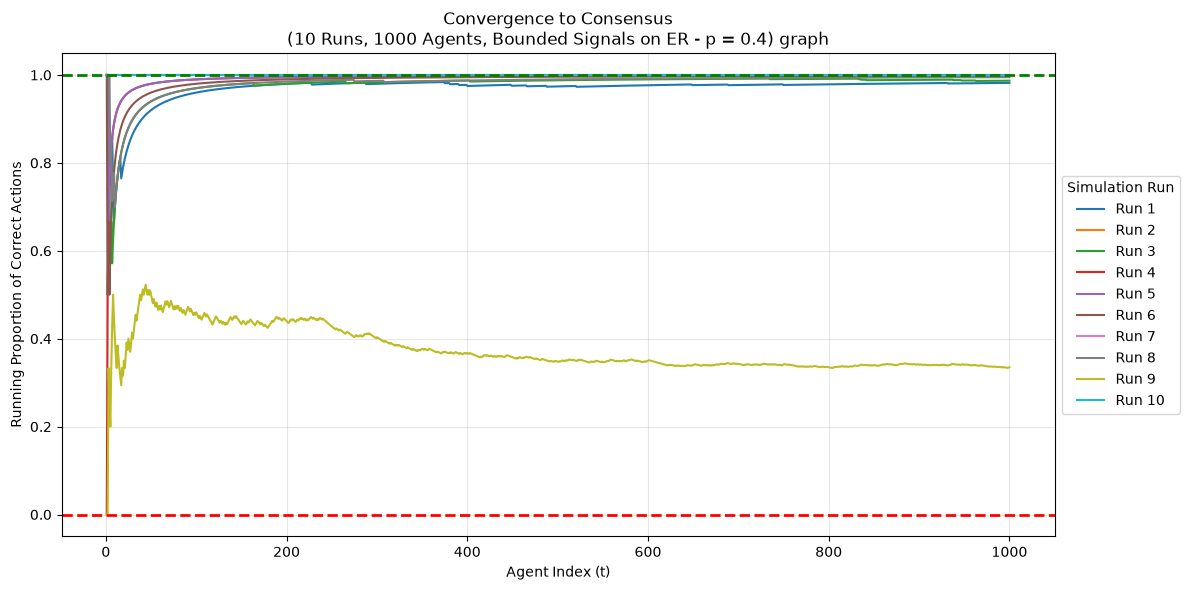

Run 1: did not converge | lock_in_index=None | final_accuracy=0.9820
Run 2: converged accurately | lock_in_index=0 | final_accuracy=1.0000
Run 3: did not converge | lock_in_index=None | final_accuracy=0.9870
Run 4: converged accurately | lock_in_index=1 | final_accuracy=0.9990
Run 5: converged accurately | lock_in_index=3 | final_accuracy=0.9990
Run 6: converged accurately | lock_in_index=4 | final_accuracy=0.9980
Run 7: converged accurately | lock_in_index=0 | final_accuracy=1.0000
Run 8: converged accurately | lock_in_index=308 | final_accuracy=0.9950
Run 9: did not converge | lock_in_index=None | final_accuracy=0.3350
Run 10: converged accurately | lock_in_index=0 | final_accuracy=1.0000
Converged runs: [2, 4, 5, 6, 7, 8, 10]
Lock-in indices: [0, 1, 3, 4, 0, 308, 0]


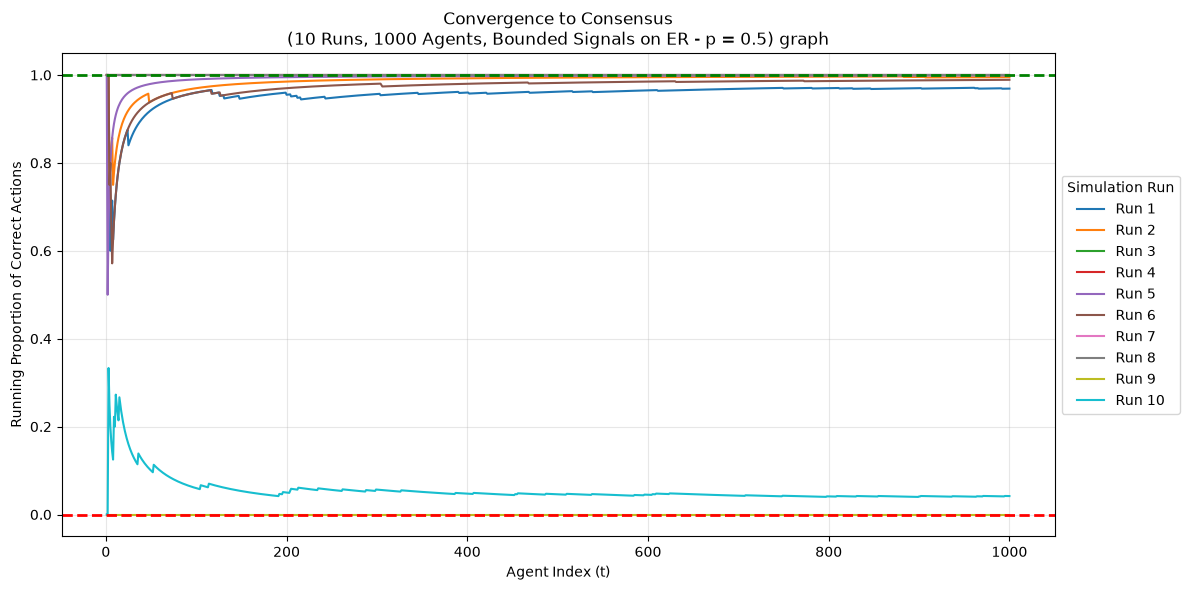

Run 1: did not converge | lock_in_index=None | final_accuracy=0.9690
Run 2: did not converge | lock_in_index=None | final_accuracy=0.9950
Run 3: converged accurately | lock_in_index=0 | final_accuracy=1.0000
Run 4: converged accurately | lock_in_index=0 | final_accuracy=1.0000
Run 5: converged accurately | lock_in_index=2 | final_accuracy=0.9990
Run 6: converged accurately | lock_in_index=773 | final_accuracy=0.9890
Run 7: converged accurately | lock_in_index=0 | final_accuracy=1.0000
Run 8: converged accurately | lock_in_index=0 | final_accuracy=1.0000
Run 9: converged inaccurately | lock_in_index=0 | final_accuracy=0.0000
Run 10: did not converge | lock_in_index=None | final_accuracy=0.0420
Converged runs: [3, 4, 5, 6, 7, 8, 9]
Lock-in indices: [0, 0, 2, 773, 0, 0, 0]


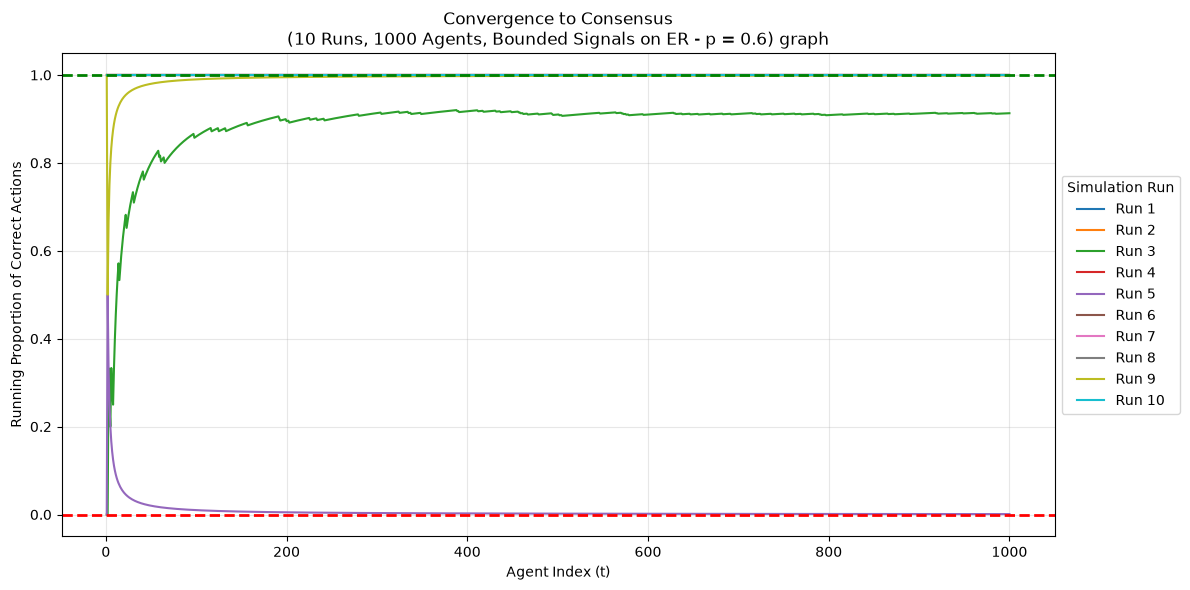

Run 1: converged accurately | lock_in_index=0 | final_accuracy=1.0000
Run 2: converged accurately | lock_in_index=0 | final_accuracy=1.0000
Run 3: did not converge | lock_in_index=None | final_accuracy=0.9130
Run 4: converged accurately | lock_in_index=0 | final_accuracy=1.0000
Run 5: converged inaccurately | lock_in_index=2 | final_accuracy=0.0010
Run 6: converged accurately | lock_in_index=0 | final_accuracy=1.0000
Run 7: converged accurately | lock_in_index=0 | final_accuracy=1.0000
Run 8: converged accurately | lock_in_index=0 | final_accuracy=1.0000
Run 9: converged accurately | lock_in_index=2 | final_accuracy=0.9990
Run 10: converged accurately | lock_in_index=0 | final_accuracy=1.0000
Converged runs: [1, 2, 4, 5, 6, 7, 8, 9, 10]
Lock-in indices: [0, 0, 0, 2, 0, 0, 0, 2, 0]


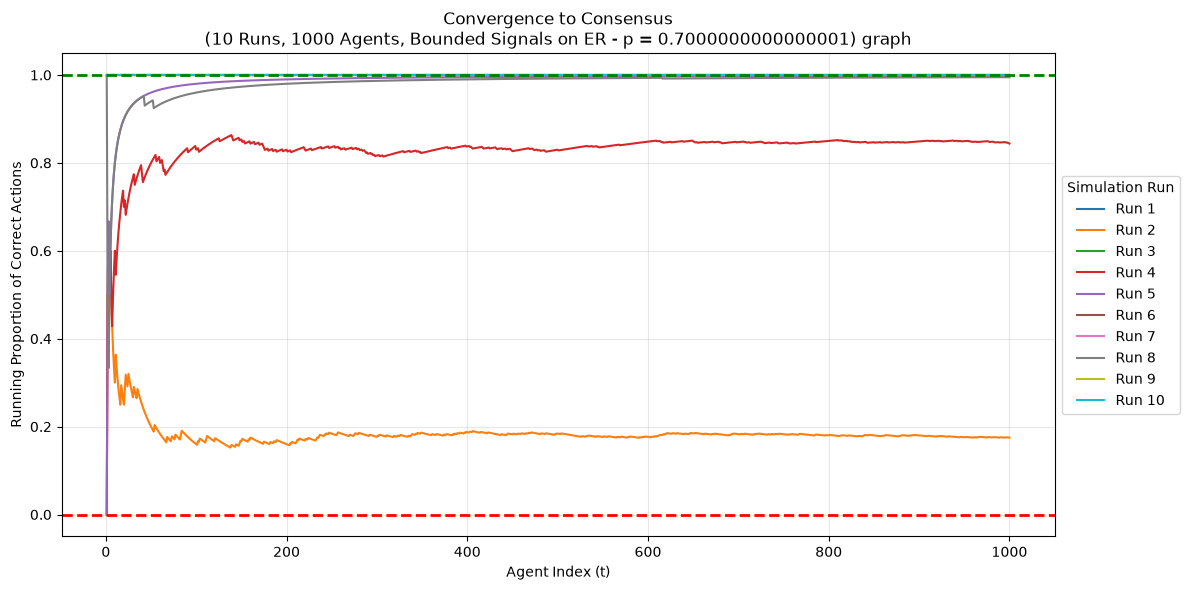

Run 1: converged accurately | lock_in_index=0 | final_accuracy=1.0000
Run 2: did not converge | lock_in_index=None | final_accuracy=0.1750
Run 3: converged accurately | lock_in_index=0 | final_accuracy=1.0000
Run 4: did not converge | lock_in_index=None | final_accuracy=0.8440
Run 5: converged accurately | lock_in_index=4 | final_accuracy=0.9980
Run 6: converged accurately | lock_in_index=0 | final_accuracy=1.0000
Run 7: converged accurately | lock_in_index=0 | final_accuracy=1.0000
Run 8: converged accurately | lock_in_index=616 | final_accuracy=0.9950
Run 9: converged accurately | lock_in_index=0 | final_accuracy=1.0000
Run 10: converged accurately | lock_in_index=0 | final_accuracy=1.0000
Converged runs: [1, 3, 5, 6, 7, 8, 9, 10]
Lock-in indices: [0, 0, 4, 0, 0, 616, 0, 0]


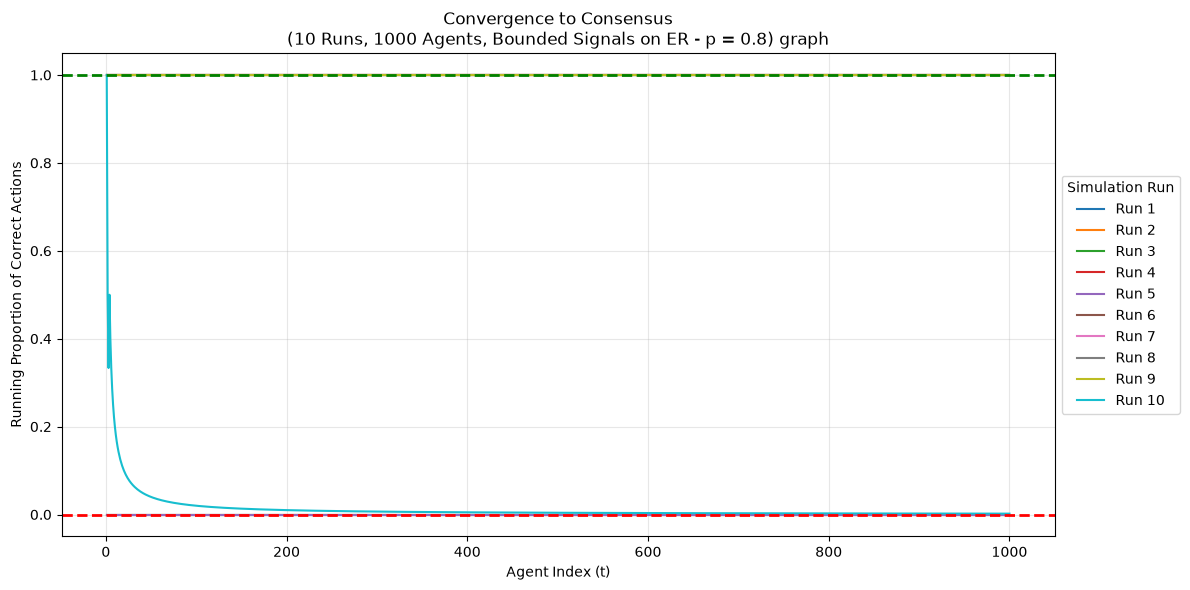

Run 1: converged accurately | lock_in_index=0 | final_accuracy=1.0000
Run 2: converged accurately | lock_in_index=0 | final_accuracy=1.0000
Run 3: converged inaccurately | lock_in_index=0 | final_accuracy=0.0000
Run 4: converged inaccurately | lock_in_index=0 | final_accuracy=0.0000
Run 5: converged inaccurately | lock_in_index=0 | final_accuracy=0.0000
Run 6: converged accurately | lock_in_index=0 | final_accuracy=1.0000
Run 7: converged accurately | lock_in_index=0 | final_accuracy=1.0000
Run 8: converged accurately | lock_in_index=0 | final_accuracy=1.0000
Run 9: converged accurately | lock_in_index=0 | final_accuracy=1.0000
Run 10: converged inaccurately | lock_in_index=4 | final_accuracy=0.0020
Converged runs: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10]
Lock-in indices: [0, 0, 0, 0, 0, 0, 0, 0, 0, 4]


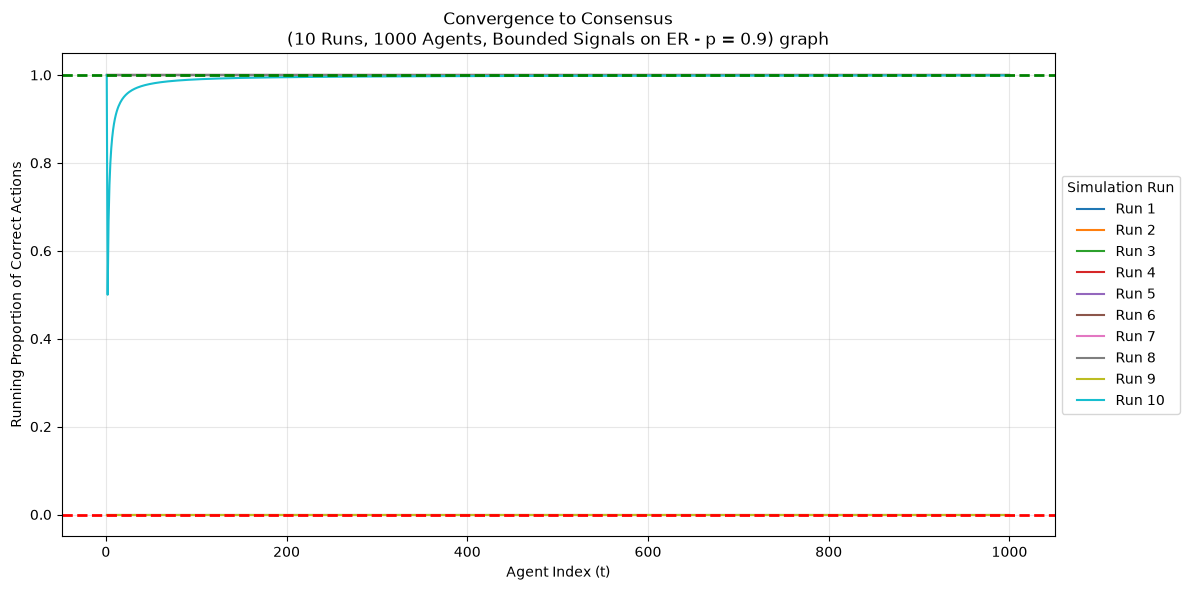

Run 1: converged accurately | lock_in_index=0 | final_accuracy=1.0000
Run 2: converged inaccurately | lock_in_index=0 | final_accuracy=0.0000
Run 3: converged accurately | lock_in_index=0 | final_accuracy=1.0000
Run 4: converged accurately | lock_in_index=0 | final_accuracy=1.0000
Run 5: converged inaccurately | lock_in_index=0 | final_accuracy=0.0000
Run 6: converged accurately | lock_in_index=0 | final_accuracy=1.0000
Run 7: converged accurately | lock_in_index=0 | final_accuracy=1.0000
Run 8: converged accurately | lock_in_index=0 | final_accuracy=1.0000
Run 9: converged inaccurately | lock_in_index=0 | final_accuracy=0.0000
Run 10: converged accurately | lock_in_index=2 | final_accuracy=0.9990
Converged runs: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10]
Lock-in indices: [0, 0, 0, 0, 0, 0, 0, 0, 0, 2]


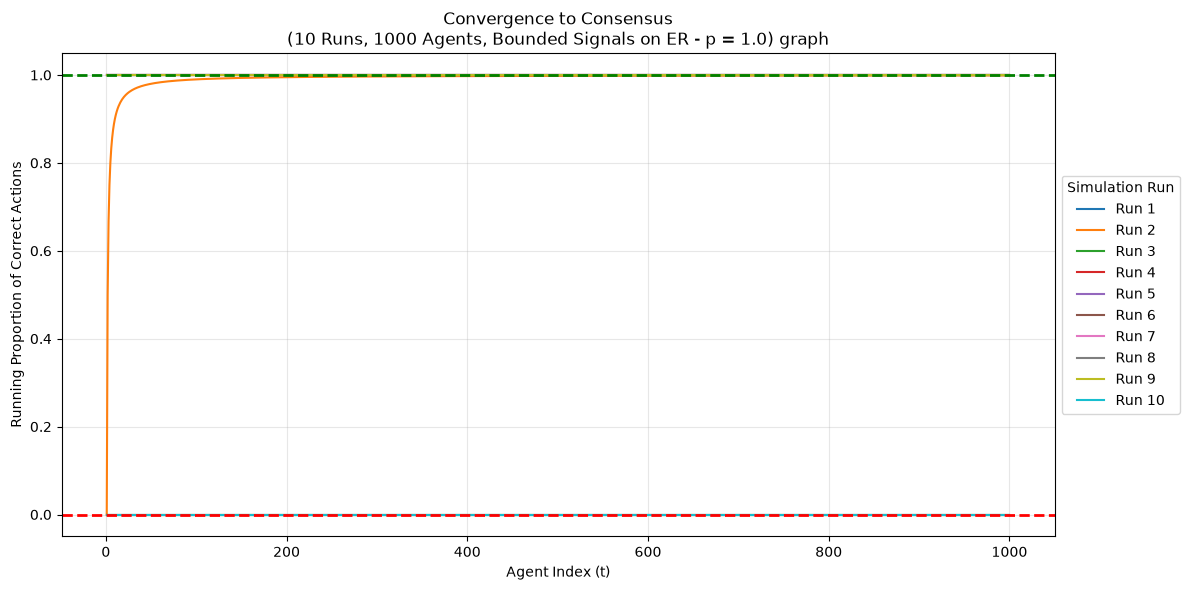

Run 1: converged accurately | lock_in_index=0 | final_accuracy=1.0000
Run 2: converged accurately | lock_in_index=1 | final_accuracy=0.9990
Run 3: converged inaccurately | lock_in_index=0 | final_accuracy=0.0000
Run 4: converged accurately | lock_in_index=0 | final_accuracy=1.0000
Run 5: converged accurately | lock_in_index=0 | final_accuracy=1.0000
Run 6: converged inaccurately | lock_in_index=0 | final_accuracy=0.0000
Run 7: converged accurately | lock_in_index=0 | final_accuracy=1.0000
Run 8: converged accurately | lock_in_index=0 | final_accuracy=1.0000
Run 9: converged accurately | lock_in_index=0 | final_accuracy=1.0000
Run 10: converged inaccurately | lock_in_index=0 | final_accuracy=0.0000
Converged runs: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10]
Lock-in indices: [0, 1, 0, 0, 0, 0, 0, 0, 0, 0]


In [ ]:
# ER + bounded exploration

for p in np.linspace(0.1, 1, 10):
    result = run_sim('ER', 'bounded', agents=1000, runs=10, seed=123, q=0.8, p=p)
    title = f"Convergence to Consensus\n({result.params['graph_type']} Graph, {result.params['signal_type'].title()} Signals, {result.params['agents']} Agents, {result.params['runs']} Runs, p={result.params['p']:.2f})"
    plot_convergence(result, title)
    summarise_convergence_metrics(result)


In [8]:
import time

runs = 100
agents = 10000
k = 50
p = 0.5
sample = 100
planned_loops = 50
planned_runs_per_loop = 1000

start_time = time.time()
result = run_sim('NEO', 'unbounded', agents=agents, runs=runs, k=k, seed=42)
end_time = time.time()

time_per_run = (end_time - start_time) / runs
total_planned_runs = planned_loops * planned_runs_per_loop

print(f"Time per run: {time_per_run:.4f} seconds.")
print(f"Estimated time for {total_planned_runs} runs (Overnight Total): {(time_per_run * total_planned_runs) / 3600:.2f} hours.")

Time per run: 1.1201 seconds.
Estimated time for 50000 runs (Overnight Total): 15.56 hours.
